In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [14]:
df=pd.read_csv('Churn_Modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9557,9558,15757310,Otitodilichukwu,655,Germany,Male,67,6,148363.38,1,1,1,186995.17,0
4705,4706,15749489,Denisova,533,Germany,Female,22,10,115743.60,1,0,0,43852.05,0
5906,5907,15745623,Worsnop,788,France,Male,32,4,112079.58,1,0,0,89368.59,0
6247,6248,15803633,T'ien,678,France,Female,46,1,0.00,2,0,0,82106.19,0
8270,8271,15703544,Hung,559,Spain,Male,34,0,0.00,1,1,0,182988.94,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [17]:
df.shape

(10000, 11)

<Axes: xlabel='Balance', ylabel='Count'>

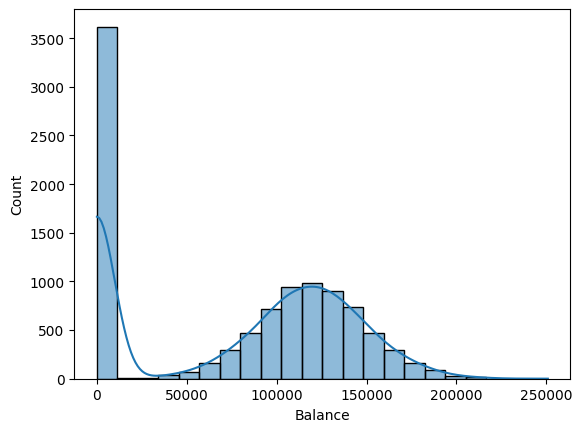

In [18]:
sns.histplot(df['Balance'],kde=True)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

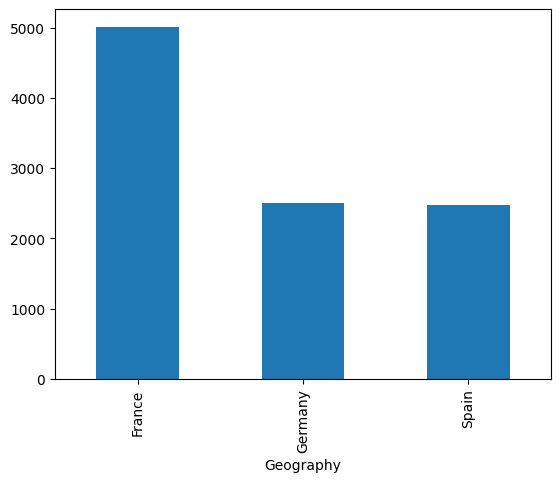

In [19]:
df['Geography'].value_counts().plot(kind='bar')
df['Geography'].value_counts()

In [20]:
x=df.drop('Exited',axis=1)
y=df['Exited']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=34)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [22]:
cat=ColumnTransformer(transformers=[
    ('gender',OneHotEncoder(drop='first'),[2]),
    ('geography',OneHotEncoder(drop='first',sparse_output=False),[1])
],remainder='passthrough')

num=ColumnTransformer(transformers=[
    ('scale',StandardScaler(),[0,1,2,3,4,5,6,7,8,9])
],remainder='passthrough')

model=DecisionTreeClassifier(criterion="entropy",max_depth=4,random_state=34)

In [ ]:
pipe=Pipeline(steps=[
    ('cat_transform',cat),
    ('num_transform',num),
    ('sampling',SMOTE(random_state=34,k_neighbors=7)), # type: ignore
    ('model',model)
])

NameError: name 'SMOTE' is not defined

In [ ]:
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)


In [ ]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.8615
0.7460815047021944
0.5483870967741935
0.6321381142098274
